<a href="https://colab.research.google.com/github/Orefle2003/AnswerTime-MetricNLP/blob/model-experiments-1/distilbert_statistical_sentiment_analysis_v1_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install spacy transformers torch
!pip install datasets
!python -m spacy download en_core_web_sm



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 17.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 93.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.l

In [ ]:
!pip install numpy==1.24.3


# Model 1

Basic NLP Distil-Bert model using "finetuned-sst-2-english" finetuning with NER (Named Entity Recognition) to calculate rudimentary sentiment distribution

In [ ]:
from transformers import pipeline
import spacy
import pandas as pd
from datasets import load_dataset
from collections import defaultdict

# Load spaCy model for Named Entity Recognition
nlp = spacy.load('en_core_web_sm')

# Load a fine-tuned sentiment analysis model for better predictions
sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", truncation=True)

# Load a slightly larger sample of the Yelp reviews dataset for testing
dataset = load_dataset("yelp_polarity", split="test[:200]")  # Increased dataset size to 200 reviews
reviews = pd.DataFrame(dataset)
documents = reviews['text'].tolist()

# Function to truncate long documents to the maximum length of 512 tokens
def truncate_document(doc, max_length=512):
    return ' '.join(doc.split()[:max_length])

# Apply truncation to all documents to ensure they are within the model's limit
truncated_documents = [truncate_document(doc) for doc in documents]

# Function to extract relevant entities (e.g., restaurant names)
def extract_relevant_entities(documents):
    entities = set()
    for doc in documents:
        spacy_doc = nlp(doc)
        for ent in spacy_doc.ents:
            # Only include entities such as organizations, places, etc.
            if ent.label_ in ['ORG', 'GPE', 'LOC']:
                entities.add(ent.text.lower())
    return entities

# Extract entities from the documents
relevant_entities = extract_relevant_entities(truncated_documents)
print("\nExtracted Entities:", relevant_entities)

# Function to analyze sentiment for each entity
def analyze_entity_sentiment(documents, entities):
    entity_sentiment_counts = defaultdict(lambda: {'positive': 0, 'negative': 0, 'neutral': 0, 'total': 0})

    for doc in documents:
        for entity in entities:
            if entity in doc.lower():  # Check if the entity is mentioned in the document
                sentiment = sentiment_model(doc[:512])  # Truncate to model's max input size
                label = sentiment[0]['label']
                entity_sentiment_counts[entity]['total'] += 1
                if label == 'POSITIVE':
                    entity_sentiment_counts[entity]['positive'] += 1
                elif label == 'NEGATIVE':
                    entity_sentiment_counts[entity]['negative'] += 1
                else:
                    entity_sentiment_counts[entity]['neutral'] += 1

    # Calculate and print the percentage of positive mentions for each entity
    for entity, counts in entity_sentiment_counts.items():
        if counts['total'] > 0:
            positive_pct = (counts['positive'] / counts['total']) * 100
            print(f"{positive_pct:.2f}% of reviewers mentioned '{entity}' positively out of {counts['total']} mentions.")
        else:
            print(f"No mentions of '{entity}' found.")

# Run the sentiment analysis function
analyze_entity_sentiment(truncated_documents, relevant_entities)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

train-00000-of-00001.parquet:   0%|          | 0.00/256M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/38000 [00:00<?, ? examples/s]


Extracted Entities: {"a master stylist women's", 'd.c.', 'rock bottom brewery', 'the lobster roll', 'us', 'sysco', 'pittsburgh', 'houston', 'chicken', 'schnitzel', 'koh samui thailand', "little caesar's", 'orient', 'ct', 'chaitiyana', 'd', 'avocado', 'the harris theater', 'whole foods', 'wow', 'portugal', 'london', 'slushy', 'caramel', '\\""miss pat\\""--another', 'pitt', 'blues', 'hmmmmm', 'ham & cheese sandwiches', 'downtown pittsburgh', 'the west busway', 'barnes & noble', 'roland', 'yuenglings', 'dormont', 'mortons', 'sea scallops & octopus', 'pennsylvania', 'pgh', 'colnago', 'heinz', 'brighton heights', 'unos', 'point breeze', 'potato gnocchi', 'the old fishmarket', 'the red alert', "tessaro's", "men's", 'mcn', 'reyna foods', 'instagram', 'ravioli & salmon', 'battleship', 'the decor & old', 'atomic', 'new haven', 'mediocre', 'really', "\\n\\ni'd", 'giant eagle', 'wholleys', 'caribbean', 'the north side', 'redfin blues', 'pizza hut', 'the renaissance hotel', 'wiener schnitzel', 'f

# model 2
Entity-Aware Sentiment Analyzer (EASA)

The model focuses on extracting relevant entities and analyses their sentiment.

In [ ]:
from transformers import pipeline
import spacy
import pandas as pd
from datasets import load_dataset
from collections import defaultdict

# Load spaCy model for Named Entity Recognition
nlp = spacy.load('en_core_web_sm')

# Load a fine-tuned sentiment analysis model for better predictions
sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", truncation=True)

# Load a slightly larger sample of the Yelp reviews dataset for testing
dataset = load_dataset("yelp_polarity", split="test[:1000]")  # Increased dataset size to 200 reviews
reviews = pd.DataFrame(dataset)
documents = reviews['text'].tolist()

# Function to truncate long documents to the maximum length of 512 tokens
def truncate_document(doc, max_length=512):
    return ' '.join(doc.split()[:max_length])

# Apply truncation to all documents to ensure they are within the model's limit
truncated_documents = [truncate_document(doc) for doc in documents]

# Function to extract relevant entities with refined filters
def extract_relevant_entities(documents):
    entities = defaultdict(int)  # Track entity frequencies
    for doc in documents:
        spacy_doc = nlp(doc)
        for ent in spacy_doc.ents:
            # Include only organizations (ORG), geopolitical entities (GPE), and locations (LOC)
            if ent.label_ in ['ORG', 'GPE', 'LOC']:
                entity_text = ent.text.strip().lower()
                # Filter out irrelevant entities
                if len(entity_text.split()) > 1 or entity_text.istitle():  # Allow multi-word or title-case entities
                    entities[entity_text] += 1

    # Apply additional filtering: exclude low-frequency and irrelevant entities
    filtered_entities = {entity for entity, count in entities.items() if count > 1}  # Only keep entities mentioned > 1
    return filtered_entities

# Extract entities from the documents
relevant_entities = extract_relevant_entities(truncated_documents)
print("\nFiltered Entities:", relevant_entities)

# Function to analyze sentiment for each entity
def analyze_entity_sentiment(documents, entities):
    entity_sentiment_counts = defaultdict(lambda: {'positive': 0, 'negative': 0, 'neutral': 0, 'total': 0})

    for doc in documents:
        for entity in entities:
            if entity in doc.lower():  # Check if the entity is mentioned in the document
                sentiment = sentiment_model(doc[:512])  # Truncate to model's max input size
                label = sentiment[0]['label']
                entity_sentiment_counts[entity]['total'] += 1
                if label == 'POSITIVE':
                    entity_sentiment_counts[entity]['positive'] += 1
                elif label == 'NEGATIVE':
                    entity_sentiment_counts[entity]['negative'] += 1
                else:
                    entity_sentiment_counts[entity]['neutral'] += 1

    # Calculate and print the percentage of positive mentions for each entity
    for entity, counts in entity_sentiment_counts.items():
        if counts['total'] > 0:
            positive_pct = (counts['positive'] / counts['total']) * 100
            print(f"{positive_pct:.2f}% of reviewers mentioned '{entity}' positively out of {counts['total']} mentions.")
        else:
            print(f"No mentions of '{entity}' found.")

# Run the sentiment analysis function
analyze_entity_sentiment(truncated_documents, relevant_entities)


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.



Filtered Entities: {'the home depot', 'the capital brewery', 'zimbrick vw', 'la tolteca', 'el nopalito', 'home depot', 'the phoenix zoo', 'time warner', 'port authority', 'caring hands', 'southern california', 'athenian express', 'rock bottom', 'the queen city', 'super 8', "tully's ii", 'university city', 'capital grille', 'cooperstown sports grill', 'time warner cable', 'us airways center', 'cracker barrel', 'taco bell', "common ground's", 'the us airways center', 'us airways', 'front row', 'whole foods', 'gabriel brothers', 'south hills', 'penn mac', 'hyde park', 'china palace', 'north carolina', 'thai house', 'alice springs chicken', 'big burrito', 'wiener schnitzel', 'san diego', '4th ward', 'common ground', 'the phoenix art museum', 'giant eagle', 'new york', 'the pear and gorgonzola'}
100.00% of reviewers mentioned 'gabriel brothers' positively out of 1 mentions.
66.67% of reviewers mentioned 'rock bottom' positively out of 3 mentions.
66.67% of reviewers mentioned 'whole foods'

# Model 3

Topic Modeling with Sentiment Mapping
Method: Use a topic modeling library like BERTopic to extract topics discussed in the reviews and map sentiment scores to each topic.
Goal: Provide insights such as:
"Topic A (service) is mentioned positively in 70% of reviews."
"Topic B (food quality) has a 40% negative sentiment."

In [ ]:
from transformers import pipeline
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from datasets import load_dataset
import pandas as pd
from collections import defaultdict
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Load fine-tuned sentiment analysis model
sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", truncation=True)

# Load Yelp reviews dataset
dataset = load_dataset("yelp_polarity", split="test[:200]")  # Use a subset of the dataset for testing
reviews = pd.DataFrame(dataset)
documents = reviews['text'].tolist()

# Truncate documents to fit model's token limit
def truncate_document(doc, max_length=512):
    return ' '.join(doc.split()[:max_length])

truncated_documents = [truncate_document(doc) for doc in documents]

# Generate a dynamic stop-word list based on term frequency
from collections import Counter
all_words = ' '.join(truncated_documents).lower().split()
most_common_words = [word for word, _ in Counter(all_words).most_common(50)]  # Top 50 most frequent words
dynamic_stop_words = list(set(most_common_words + list(ENGLISH_STOP_WORDS)))  # Convert to list

# Generate topics using BERTopic
vectorizer_model = CountVectorizer(stop_words=dynamic_stop_words, ngram_range=(1, 3))
topic_model = BERTopic(vectorizer_model=vectorizer_model, nr_topics="auto")  # Automatically reduce noise in topics
topics, probs = topic_model.fit_transform(truncated_documents)

# Map sentences to topics for detailed sentiment analysis
sentences_per_topic = defaultdict(list)
for doc, topic in zip(truncated_documents, topics):
    if topic != -1:  # Exclude outliers
        sentences_per_topic[topic].append(doc)

# Perform sentiment analysis and aggregate scores by topic
topic_sentiment = defaultdict(lambda: {"positive": 0, "negative": 0, "total": 0})

for topic, sentences in sentences_per_topic.items():
    for sentence in sentences:
        sentiment = sentiment_model(sentence[:512])  # Truncate to model's max input size
        label = sentiment[0]['label']
        topic_sentiment[topic]["total"] += 1
        if label == "POSITIVE":
            topic_sentiment[topic]["positive"] += 1
        elif label == "NEGATIVE":
            topic_sentiment[topic]["negative"] += 1

# Print insights for each topic
for topic, sentiment in topic_sentiment.items():
    total = sentiment["total"]
    if total > 0:
        positive_pct = (sentiment["positive"] / total) * 100
        negative_pct = (sentiment["negative"] / total) * 100
        print(f"Topic {topic}:")
        print(f"  - Positive Sentiment: {positive_pct:.2f}%")
        print(f"  - Negative Sentiment: {negative_pct:.2f}%")
        print(f"  - Example Keywords: {topic_model.get_topic(topic)}")
        print()


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


Topic 0:
  - Positive Sentiment: 55.17%
  - Negative Sentiment: 44.83%
  - Example Keywords: [('time', 0.011660498826360156), ('great', 0.010151014846837175), ('restaurant', 0.009931514282906272), ('service', 0.009089217054508936), ('got', 0.00894784924488207), ('pittsburgh', 0.008762045898978698), ('didnt', 0.008695396582672058), ('best', 0.008246705358259936), ('really', 0.007844646413896067), ('dont', 0.007775306383641421)]

Topic 1:
  - Positive Sentiment: 58.33%
  - Negative Sentiment: 41.67%
  - Example Keywords: [('cut', 0.04372502113793714), ('hair', 0.029751338797600876), ('said', 0.02462031972409449), ('wasnt', 0.022532779472775342), ('went', 0.018493102473054294), ('helmet', 0.01788457257315994), ('jacket', 0.01788457257315994), ('dont', 0.017132090067817372), ('ended', 0.017108257845638093), ('oh', 0.015509589846997074)]



#Model 4
Comparison and Benchmark Analysis


Perform comparative analysis across subsets of text to extract metrics that highlight differences in sentiment, frequency, or themes. This can provide insights into how entities, time periods, or categories compare against each other.

In [ ]:
from transformers import pipeline
from datasets import load_dataset
import spacy
from collections import defaultdict, Counter
import pandas as pd

# Load fine-tuned sentiment analysis model
sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", truncation=True)

# Load spaCy model for Named Entity Recognition (NER)
nlp = spacy.load("en_core_web_sm")

# Load Yelp reviews dataset
dataset = load_dataset("yelp_polarity", split="test[:200]")  # Subset for testing
reviews = pd.DataFrame(dataset)
documents = reviews['text'].tolist()

# Function to truncate long documents to fit the model's limit
def truncate_document(doc, max_length=512):
    return ' '.join(doc.split()[:max_length])

truncated_documents = [truncate_document(doc) for doc in documents]

# Function to extract all entities and their frequency
def extract_entities(documents):
    entity_counts = Counter()
    entity_context = defaultdict(list)  # Store the sentences where entities occur
    for doc in documents:
        spacy_doc = nlp(doc)
        for ent in spacy_doc.ents:
            if ent.label_ in ["ORG", "GPE"]:  # Focus on organizations and locations
                entity_counts[ent.text.lower()] += 1
                entity_context[ent.text.lower()].append(doc)
    return entity_counts, entity_context

# Extract entities and their contexts
entity_counts, entity_context = extract_entities(truncated_documents)

# Filter entities dynamically based on frequency (e.g., >2 mentions)
relevant_entities = {entity: docs for entity, count in entity_counts.items() if count > 2}

# Analyze sentiment for each relevant entity
group_sentiment = defaultdict(lambda: {"positive": 0, "negative": 0, "neutral": 0, "total": 0})

for entity, docs in relevant_entities.items():
    for doc in entity_context[entity]:
        sentiment = sentiment_model(doc[:512])  # Truncate to model's max input size
        label = sentiment[0]['label']
        group_sentiment[entity]["total"] += 1
        if label == "POSITIVE":
            group_sentiment[entity]["positive"] += 1
        elif label == "NEGATIVE":
            group_sentiment[entity]["negative"] += 1
        else:
            group_sentiment[entity]["neutral"] += 1

# Print comparative insights
for entity, sentiment in group_sentiment.items():
    total = sentiment["total"]
    if total > 0:
        positive_pct = (sentiment["positive"] / total) * 100
        negative_pct = (sentiment["negative"] / total) * 100
        print(f"Entity: {entity.capitalize()}")
        print(f"  - Positive Sentiment: {positive_pct:.2f}%")
        print(f"  - Negative Sentiment: {negative_pct:.2f}%")
        print(f"  - Total Mentions: {total}")
        print()


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


Entity: Waterfront
  - Positive Sentiment: 66.67%
  - Negative Sentiment: 33.33%
  - Total Mentions: 3

Entity: Pittsburgh
  - Positive Sentiment: 51.16%
  - Negative Sentiment: 48.84%
  - Total Mentions: 43

Entity: D&b
  - Positive Sentiment: 0.00%
  - Negative Sentiment: 100.00%
  - Total Mentions: 4

Entity: Bbb
  - Positive Sentiment: 0.00%
  - Negative Sentiment: 100.00%
  - Total Mentions: 4

Entity: Oakland
  - Positive Sentiment: 33.33%
  - Negative Sentiment: 66.67%
  - Total Mentions: 3

Entity: Whole foods
  - Positive Sentiment: 100.00%
  - Negative Sentiment: 0.00%
  - Total Mentions: 6

Entity: Casbah
  - Positive Sentiment: 100.00%
  - Negative Sentiment: 0.00%
  - Total Mentions: 7

Entity: Atm
  - Positive Sentiment: 100.00%
  - Negative Sentiment: 0.00%
  - Total Mentions: 3

Entity: Wiener schnitzel
  - Positive Sentiment: 0.00%
  - Negative Sentiment: 100.00%
  - Total Mentions: 3

Entity: Really
  - Positive Sentiment: 0.00%
  - Negative Sentiment: 100.00%
  - Tot

# Model 4 - Detected Anomalies

In [ ]:
from transformers import pipeline
from datasets import load_dataset
import spacy
from collections import defaultdict, Counter
import numpy as np  # Correctly import NumPy
import pandas as pd


# Load fine-tuned sentiment analysis model
sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", truncation=True)

# Load spaCy model for Named Entity Recognition (NER)
nlp = spacy.load("en_core_web_sm")

# Load Yelp reviews dataset
dataset = load_dataset("yelp_polarity", split="test[:200]")  # Subset for testing
reviews = pd.DataFrame(dataset)
documents = reviews['text'].tolist()

# Function to truncate long documents to fit the model's limit
def truncate_document(doc, max_length=512):
    return ' '.join(doc.split()[:max_length])

truncated_documents = [truncate_document(doc) for doc in documents]

# Function to extract entities from the dataset
def extract_entities(documents):
    entity_context = defaultdict(list)  # Store the sentences where entities occur
    for doc in documents:
        spacy_doc = nlp(doc)
        for ent in spacy_doc.ents:
            if ent.label_ in ["ORG", "GPE"]:  # Focus on organizations and locations
                entity_context[ent.text.lower()].append(doc)
    return entity_context

# Extract entities and their contexts
entity_context = extract_entities(truncated_documents)

# Perform sentiment analysis for each entity
entity_sentiment = defaultdict(lambda: {"positive": 0, "negative": 0, "neutral": 0, "total": 0, "score": 0})

for entity, docs in entity_context.items():
    for doc in docs:
        sentiment = sentiment_model(doc[:512])  # Truncate to model's max input size
        label = sentiment[0]['label']
        entity_sentiment[entity]["total"] += 1
        if label == "POSITIVE":
            entity_sentiment[entity]["positive"] += 1
            entity_sentiment[entity]["score"] += 1  # Assign +1 for positive sentiment
        elif label == "NEGATIVE":
            entity_sentiment[entity]["negative"] += 1
            entity_sentiment[entity]["score"] -= 1  # Assign -1 for negative sentiment

# Calculate overall sentiment metrics for anomaly detection
scores = [data["score"] / data["total"] for data in entity_sentiment.values()]
mean_score = np.mean(scores)
std_dev_score = np.std(scores)

# Adjust z-score threshold for sensitivity
sensitivity_threshold = 0.05  # Lower for higher sensitivity

# Detect anomalies based on adjusted z-scores
anomalies = {}
for entity, data in entity_sentiment.items():
    if data["total"] > 1:  # Ensure sufficient data for the entity
        entity_avg_score = data["score"] / data["total"]
        z_score = (entity_avg_score - mean_score) / std_dev_score
        if abs(z_score) > sensitivity_threshold:  # Lower threshold for higher sensitivity
            anomalies[entity] = {
                "z_score": z_score,
                "positive": (data["positive"] / data["total"]) * 100,
                "negative": (data["negative"] / data["total"]) * 100,
                "total_mentions": data["total"]
            }

# Print anomalies
print("Detected Anomalies:")
for entity, data in anomalies.items():
    print(f"Entity: {entity.capitalize()}")
    print(f"  - Z-Score: {data['z_score']:.2f}")
    print(f"  - Positive Sentiment: {data['positive']:.2f}%")
    print(f"  - Negative Sentiment: {data['negative']:.2f}%")
    print(f"  - Total Mentions: {data['total_mentions']}")
    print()


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


Detected Anomalies:
Entity: Pittsburgh
  - Z-Score: -0.08
  - Positive Sentiment: 51.16%
  - Negative Sentiment: 48.84%
  - Total Mentions: 43

Entity: D&b
  - Z-Score: -1.14
  - Positive Sentiment: 0.00%
  - Negative Sentiment: 100.00%
  - Total Mentions: 4

Entity: Unos
  - Z-Score: 0.93
  - Positive Sentiment: 100.00%
  - Negative Sentiment: 0.00%
  - Total Mentions: 2

Entity: Hint
  - Z-Score: -1.14
  - Positive Sentiment: 0.00%
  - Negative Sentiment: 100.00%
  - Total Mentions: 2

Entity: Bbb
  - Z-Score: -1.14
  - Positive Sentiment: 0.00%
  - Negative Sentiment: 100.00%
  - Total Mentions: 5

Entity: Arl
  - Z-Score: -1.14
  - Positive Sentiment: 0.00%
  - Negative Sentiment: 100.00%
  - Total Mentions: 2

Entity: Whole foods
  - Z-Score: 0.93
  - Positive Sentiment: 100.00%
  - Negative Sentiment: 0.00%
  - Total Mentions: 5

Entity: Giant eagle
  - Z-Score: -0.10
  - Positive Sentiment: 50.00%
  - Negative Sentiment: 50.00%
  - Total Mentions: 2

Entity: Pennsylvania
  - Z-S

# Features to Implement

*   Advanced Topic Modeling
*   Outlier Detection
*   Reviewer Demographics Analysis
*   Comparative Analysis
*   Emotion Detection
*   Word Cloud Visualization
*   Contextual Sentiment
*   Entity Mention Heatmaps
*   Temporal Trends

*   Statistical Co-occurrence Analysis
*   Frequency Analysis for Common Themes
*   Distribution of Ratings
*   Key Phrase and Adjective Extraction
*   Net Promoter Insights
*   Percentages of Neutral Sentiments
*   Correlation Between Sentiment and Length
*   Keyword Trends
*   Predictive Insights


## twitter dataset - detect anomalies

In [ ]:
from transformers import pipeline
from datasets import load_dataset
import spacy
from collections import defaultdict
import numpy as np  # Correctly import NumPy
import pandas as pd

# Load fine-tuned sentiment analysis model
sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", truncation=True)

# Load spaCy model for Named Entity Recognition (NER)
nlp = spacy.load("en_core_web_sm")

# Load Twitter dataset (Sentiment140)
dataset = load_dataset("sentiment140", split="train[:5000]")  # Use a subset of 1,000 tweets for testing
tweets = pd.DataFrame(dataset)
documents = tweets['text'].tolist()  # Extract tweet text

# Function to truncate long tweets to fit the model's limit
def truncate_document(doc, max_length=512):
    return ' '.join(doc.split()[:max_length])

truncated_documents = [truncate_document(doc) for doc in documents]

# Function to extract entities from the dataset
def extract_entities(documents):
    entity_context = defaultdict(list)  # Store the sentences where entities occur
    for doc in documents:
        spacy_doc = nlp(doc)
        for ent in spacy_doc.ents:
            if ent.label_ in ["ORG", "GPE"]:  # Focus on organizations and locations
                entity_context[ent.text.lower()].append(doc)
    return entity_context

# Extract entities and their contexts
entity_context = extract_entities(truncated_documents)

# Perform sentiment analysis for each entity
entity_sentiment = defaultdict(lambda: {"positive": 0, "negative": 0, "neutral": 0, "total": 0, "score": 0})

for entity, docs in entity_context.items():
    for doc in docs:
        sentiment = sentiment_model(doc[:512])  # Truncate to model's max input size
        label = sentiment[0]['label']
        entity_sentiment[entity]["total"] += 1
        if label == "POSITIVE":
            entity_sentiment[entity]["positive"] += 1
            entity_sentiment[entity]["score"] += 1  # Assign +1 for positive sentiment
        elif label == "NEGATIVE":
            entity_sentiment[entity]["negative"] += 1
            entity_sentiment[entity]["score"] -= 1  # Assign -1 for negative sentiment

# Calculate overall sentiment metrics for anomaly detection
scores = [data["score"] / data["total"] for data in entity_sentiment.values()]
mean_score = np.mean(scores)
std_dev_score = np.std(scores)

# Adjust z-score threshold for sensitivity
sensitivity_threshold = 0.05  # Lower for higher sensitivity

# Detect anomalies based on adjusted z-scores
anomalies = {}
for entity, data in entity_sentiment.items():
    if data["total"] > 1:  # Ensure sufficient data for the entity
        entity_avg_score = data["score"] / data["total"]
        z_score = (entity_avg_score - mean_score) / std_dev_score
        if abs(z_score) > sensitivity_threshold:  # Lower threshold for higher sensitivity
            anomalies[entity] = {
                "z_score": z_score,
                "positive": (data["positive"] / data["total"]) * 100,
                "negative": (data["negative"] / data["total"]) * 100,
                "total_mentions": data["total"]
            }

# Print anomalies
print("Detected Anomalies:")
for entity, data in anomalies.items():
    print(f"Entity: {entity.capitalize()}")
    print(f"  - Z-Score: {data['z_score']:.2f}")
    print(f"  - Positive Sentiment: {data['positive']:.2f}%")
    print(f"  - Negative Sentiment: {data['negative']:.2f}%")
    print(f"  - Total Mentions: {data['total_mentions']}")
    print()


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


Detected Anomalies:
Entity: Lol
  - Z-Score: 0.22
  - Positive Sentiment: 26.67%
  - Negative Sentiment: 73.33%
  - Total Mentions: 15

Entity: Dallas
  - Z-Score: 0.40
  - Positive Sentiment: 33.33%
  - Negative Sentiment: 66.67%
  - Total Mentions: 3

Entity: Fml
  - Z-Score: 0.18
  - Positive Sentiment: 25.00%
  - Negative Sentiment: 75.00%
  - Total Mentions: 4

Entity: House
  - Z-Score: -0.13
  - Positive Sentiment: 13.33%
  - Negative Sentiment: 86.67%
  - Total Mentions: 15

Entity: India
  - Z-Score: -0.49
  - Positive Sentiment: 0.00%
  - Negative Sentiment: 100.00%
  - Total Mentions: 2

Entity: Heroes
  - Z-Score: 0.40
  - Positive Sentiment: 33.33%
  - Negative Sentiment: 66.67%
  - Total Mentions: 3

Entity: Chicago
  - Z-Score: 0.85
  - Positive Sentiment: 50.00%
  - Negative Sentiment: 50.00%
  - Total Mentions: 4

Entity: Ny
  - Z-Score: 0.40
  - Positive Sentiment: 33.33%
  - Negative Sentiment: 66.67%
  - Total Mentions: 3

Entity: California
  - Z-Score: 0.58
  - Po

## word cloud visualisation - twitter dataset

In [ ]:
!pip install wordcloud matplotlib


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
/usr/local/lib/python3.10/dist-packages/spacy/util.py:1740: UserWarning: [W111] Jupyter notebook detected: if using `prefer_gpu()` or `require_gpu()`, include it in the same cell right before `spacy.load()` to ensure that the model is loaded on the correct device. More information: http://spacy.io/usage/v3#jupyter-notebook-gpu
  warnings.warn(Warnings.W111)


Generating train split:   0%|          | 0/1600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/498 [00:00<?, ? examples/s]

Detected Anomalies:
Entity: Lol
  - Z-Score: 2.36
  - Positive Sentiment: 100.00%
  - Negative Sentiment: 0.00%
  - Total Mentions: 2

Entity: Fml
  - Z-Score: -0.42
  - Positive Sentiment: 0.00%
  - Negative Sentiment: 100.00%
  - Total Mentions: 2

Entity: House
  - Z-Score: -0.42
  - Positive Sentiment: 0.00%
  - Negative Sentiment: 100.00%
  - Total Mentions: 2

Entity: Youtube
  - Z-Score: -0.42
  - Positive Sentiment: 0.00%
  - Negative Sentiment: 100.00%
  - Total Mentions: 2

Entity: Michigan
  - Z-Score: -0.42
  - Positive Sentiment: 0.00%
  - Negative Sentiment: 100.00%
  - Total Mentions: 2



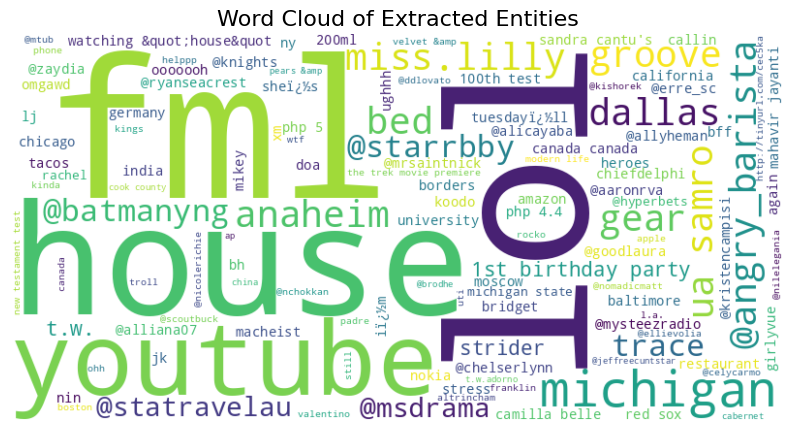

In [4]:
from transformers import pipeline
from datasets import load_dataset
import spacy
from collections import defaultdict
import numpy as np  # Correctly import NumPy
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load fine-tuned sentiment analysis model
sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", truncation=True)

# Load spaCy model for Named Entity Recognition (NER)
nlp = spacy.load("en_core_web_sm")

# Load Twitter dataset (Sentiment140)
dataset = load_dataset("sentiment140", split="train[:500]")  # Use a subset for testing
tweets = pd.DataFrame(dataset)
documents = tweets['text'].tolist()  # Extract tweet text

# Function to truncate long tweets to fit the model's limit
def truncate_document(doc, max_length=512):
    return ' '.join(doc.split()[:max_length])

truncated_documents = [truncate_document(doc) for doc in documents]

# Function to extract entities from the dataset
def extract_entities(documents):
    entity_context = defaultdict(list)  # Store the sentences where entities occur
    for doc in documents:
        spacy_doc = nlp(doc)
        for ent in spacy_doc.ents:
            if ent.label_ in ["ORG", "GPE"]:  # Focus on organizations and locations
                entity_context[ent.text.lower()].append(doc)
    return entity_context

# Extract entities and their contexts
entity_context = extract_entities(truncated_documents)

# Perform sentiment analysis for each entity
entity_sentiment = defaultdict(lambda: {"positive": 0, "negative": 0, "neutral": 0, "total": 0, "score": 0})

for entity, docs in entity_context.items():
    for doc in docs:
        sentiment = sentiment_model(doc[:512])  # Truncate to model's max input size
        label = sentiment[0]['label']
        entity_sentiment[entity]["total"] += 1
        if label == "POSITIVE":
            entity_sentiment[entity]["positive"] += 1
            entity_sentiment[entity]["score"] += 1  # Assign +1 for positive sentiment
        elif label == "NEGATIVE":
            entity_sentiment[entity]["negative"] += 1
            entity_sentiment[entity]["score"] -= 1  # Assign -1 for negative sentiment

# Calculate overall sentiment metrics for anomaly detection
scores = [data["score"] / data["total"] for data in entity_sentiment.values()]
mean_score = np.mean(scores)
std_dev_score = np.std(scores)

# Adjust z-score threshold for sensitivity
sensitivity_threshold = 0.05  # Lower for higher sensitivity

# Detect anomalies based on adjusted z-scores
anomalies = {}
for entity, data in entity_sentiment.items():
    if data["total"] > 1:  # Ensure sufficient data for the entity
        entity_avg_score = data["score"] / data["total"]
        z_score = (entity_avg_score - mean_score) / std_dev_score
        if abs(z_score) > sensitivity_threshold:  # Lower threshold for higher sensitivity
            anomalies[entity] = {
                "z_score": z_score,
                "positive": (data["positive"] / data["total"]) * 100,
                "negative": (data["negative"] / data["total"]) * 100,
                "total_mentions": data["total"]
            }

# Print anomalies
print("Detected Anomalies:")
for entity, data in anomalies.items():
    print(f"Entity: {entity.capitalize()}")
    print(f"  - Z-Score: {data['z_score']:.2f}")
    print(f"  - Positive Sentiment: {data['positive']:.2f}%")
    print(f"  - Negative Sentiment: {data['negative']:.2f}%")
    print(f"  - Total Mentions: {data['total_mentions']}")
    print()

# Create a Word Cloud for all extracted entities
def generate_word_cloud(entity_context):
    # Calculate frequencies for entities based on their number of mentions
    entity_frequencies = {entity: len(context) for entity, context in entity_context.items()}

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate_from_frequencies(entity_frequencies)

    # Display the word cloud
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Extracted Entities", fontsize=16)
    plt.show()

# Generate Word Cloud for all entities
generate_word_cloud(entity_context)


###display amazon reviews dataset

In [5]:
from datasets import load_dataset
import pandas as pd

# Load the Amazon Reviews dataset
# (You can select specific categories if needed, e.g., "Books", "Electronics", etc.)
dataset = load_dataset("amazon_polarity", split="train")  # Replace "train" with "test" if needed

# Convert the dataset to a Pandas DataFrame for easier manipulation
df = pd.DataFrame(dataset)

# Display dataset structure (columns and data types)
print("Dataset Structure:")
print(df.info())

# Display a few sample rows
print("\nSample Data:")
print(df.head())

# Check for unique items/products in the dataset (if available)
# For this version of the dataset, product titles might not exist, but you can explore its structure
if "product_title" in df.columns:
    print("\nUnique Product Titles:")
    print(df["product_title"].unique()[:10])  # Display up to 10 unique product titles

# Display a specific product's reviews (if 'product_title' exists)
specific_product = "Example Product Title"  # Replace with the actual title of interest
if "product_title" in df.columns:
    product_reviews = df[df["product_title"] == specific_product]
    print(f"\nReviews for '{specific_product}':")
    print(product_reviews)

# Display the dataset shape and summary
print("\nDataset Shape:", df.shape)
print("\nSummary Statistics:")
print(df.describe())


README.md:   0%|          | 0.00/6.81k [00:00<?, ?B/s]

train-00000-of-00004.parquet:   0%|          | 0.00/260M [00:00<?, ?B/s]

train-00001-of-00004.parquet:   0%|          | 0.00/258M [00:00<?, ?B/s]

train-00002-of-00004.parquet:   0%|          | 0.00/255M [00:00<?, ?B/s]

train-00003-of-00004.parquet:   0%|          | 0.00/254M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Dataset Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600000 entries, 0 to 3599999
Data columns (total 3 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   label    int64 
 1   title    object
 2   content  object
dtypes: int64(1), object(2)
memory usage: 82.4+ MB
None

Sample Data:
   label                                              title  \
0      1                     Stuning even for the non-gamer   
1      1              The best soundtrack ever to anything.   
2      1                                           Amazing!   
3      1                               Excellent Soundtrack   
4      1  Remember, Pull Your Jaw Off The Floor After He...   

                                             content  
0  This sound track was beautiful! It paints the ...  
1  I'm reading a lot of reviews saying that this ...  
2  This soundtrack is my favorite music of all ti...  
3  I truly like this soundtrack and I enjoy video...  
4  If you've played the game, you know h

### amazon  Time Comparison Analysis v1

Dataset Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       10000 non-null  object
 1   date       10000 non-null  object
 2   user       10000 non-null  object
 3   sentiment  10000 non-null  int64 
 4   query      10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB
None

Sample Data:
                                                text  \
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1  is upset that he can't update his Facebook by ...   
2  @Kenichan I dived many times for the ball. Man...   
3    my whole body feels itchy and like its on fire    
4  @nationwideclass no, it's not behaving at all....   

                           date             user  sentiment     query  
0  Mon Apr 06 22:19:45 PDT 2009  _TheSpecialOne_          0  NO_QUERY  
1  Mon Apr 06 22:19:49 PDT 2009    scotthamilton 

<ipython-input-10-1733722aab97>:19: FutureWarning: Parsed string "Mon Apr 06 22:19:45 PDT 2009" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


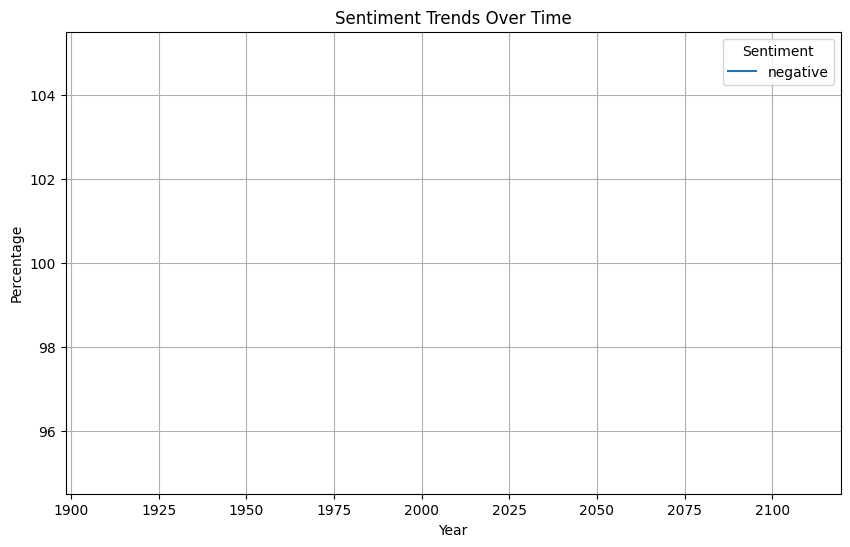

In [10]:
# Install required libraries
!pip install datasets matplotlib pandas

# Step 1: Load the Sentiment140 Dataset
from datasets import load_dataset
import pandas as pd

# Load Sentiment140 dataset (subset for faster testing)
dataset = load_dataset("sentiment140", split="train[:10000]")  # Use a subset
df = pd.DataFrame(dataset)

# Explore dataset structure
print("Dataset Structure:")
print(df.info())
print("\nSample Data:")
print(df.head())

# Step 2: Convert the 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Ensure valid dates are present
print("\nData with Parsed Dates:")
print(df[['date', 'text', 'sentiment']].head())

# Step 3: Map sentiment labels for easier analysis
# Sentiment: 0 = Negative, 4 = Positive
def map_sentiment(polarity):
    if polarity == 4:
        return "positive"
    elif polarity == 0:
        return "negative"
    else:
        return "neutral"  # This dataset does not include neutral by default

df['mapped_sentiment'] = df['sentiment'].apply(map_sentiment)

# Extract the year from the date for time comparison
df['year'] = df['date'].dt.year

# Step 4: Group sentiment by year
# Calculate the percentage of each sentiment per year
sentiment_trends = (
    df.groupby('year')['mapped_sentiment']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0) * 100
)

# Display sentiment trends
print("\nSentiment Trends Over Time:")
print(sentiment_trends)

# Step 5: Visualize Sentiment Trends Over Time
import matplotlib.pyplot as plt

# Plot sentiment trends
plt.figure(figsize=(10, 6))
sentiment_trends.plot(kind='line', ax=plt.gca(), title="Sentiment Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.legend(title="Sentiment")
plt.grid()
plt.show()
